##### Carter Williams, Matthew Del Sol, Urooj Ali 
##### Predicting Supply Chain Disruptions and Recovery Times Using Machine Learning 
##### MGS4701
##### Md Golam Kibria 

# Importing Necessary Libraries

In [7]:
# -----------------------------
# 1. Import Necessary Libraries
# -----------------------------
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import the dataset

In [9]:
# -----------------------------
# 2. Load the Dataset
# -----------------------------
df = pd.read_csv('supply_chain_disruption_recovery.csv')

# Preview the data
print(df.head())
print("Shape:", df.shape)

  disruption_id   disruption_type         industry  supplier_tier  \
0    DIS-000001  Factory Incident  Pharmaceuticals              1   
1    DIS-000002      Cyber Attack      Electronics              2   
2    DIS-000003   Port Congestion      Electronics              1   
3    DIS-000004      Labor Strike      Electronics              2   
4    DIS-000005      Geopolitical      Electronics              1   

  supplier_region supplier_size  has_backup_supplier  disruption_severity  \
0    Asia-Pacific         Large                False                    2   
1    Asia-Pacific        Medium                 True                    4   
2    Asia-Pacific         Small                 True                    2   
3          Europe         Large                 True                    1   
4   South America        Medium                 True                    2   

   production_impact_pct  revenue_loss_usd         response_type  \
0                   54.3       11376013.16        Cust

In [10]:
df

,disruption_id,disruption_type,industry,supplier_tier,supplier_region,supplier_size,has_backup_supplier,disruption_severity,production_impact_pct,revenue_loss_usd,response_type,response_time_days,partial_recovery_days,full_recovery_days,permanent_supplier_change
0,DIS-000001,Factory Incident,Pharmaceuticals,1,Asia-Pacific,Large,False,2,54.3,11376013.16,Customer Delay,14,3,59,False
1,DIS-000002,Cyber Attack,Electronics,2,Asia-Pacific,Medium,True,4,52.4,1199054.59,Alternative Supplier,1,29,97,True
2,DIS-000003,Port Congestion,Electronics,1,Asia-Pacific,Small,True,2,32.4,228848.77,Alternative Supplier,1,18,67,True
3,DIS-000004,Labor Strike,Electronics,2,Europe,Large,True,1,15.7,2257287.82,Alternative Supplier,1,18,36,False
4,DIS-000005,Geopolitical,Electronics,1,South America,Medium,True,2,32.9,965588.44,Alternative Supplier,7,11,61,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,DIS-099996,Port Congestion,Pharmaceuticals,1,North America,Medium,True,1,14.4,681354.68,Alternative Supplier,3,3,8,False
99996,DIS-099997,Port Congestion,Pharmaceuticals,2,Asia-Pacific,Large,True,3,26.6,7549732.98,Alternative Supplier,5,9,153,False
99997,DIS-099998,Port Congestion,Automotive,2,Europe,Medium,True,1,24.0,617965.56,Alternative Supplier,1,15,43,False
99998,DIS-099999,Labor Strike,Pharmaceuticals,1,South America,Medium,True,1,16.9,429525.75,Alternative Supplier,4,21,59,True


# Identifying and handling the missing values

#### Data Type Checking

In [13]:
print(df.dtypes)

# -----------------------------
# 4. Missing Values Check
# -----------------------------
print(df.isnull().sum())

disruption_id                 object
disruption_type               object
industry                      object
supplier_tier                  int64
supplier_region               object
supplier_size                 object
has_backup_supplier             bool
disruption_severity            int64
production_impact_pct        float64
revenue_loss_usd             float64
response_type                 object
response_time_days             int64
partial_recovery_days          int64
full_recovery_days             int64
permanent_supplier_change       bool
dtype: object
disruption_id                0
disruption_type              0
industry                     0
supplier_tier                0
supplier_region              0
supplier_size                0
has_backup_supplier          0
disruption_severity          0
production_impact_pct        0
revenue_loss_usd             0
response_type                0
response_time_days           0
partial_recovery_days        0
full_recovery_days          

In [14]:
print(df.describe())

       supplier_tier  disruption_severity  production_impact_pct  \
count  100000.000000        100000.000000          100000.000000   
mean        2.101210             2.497110              31.411037   
std         0.995056             1.083745              17.565837   
min         1.000000             1.000000               1.000000   
25%         1.000000             2.000000              18.400000   
50%         2.000000             2.000000              30.100000   
75%         3.000000             3.000000              42.900000   
max         4.000000             5.000000             100.000000   

       revenue_loss_usd  response_time_days  partial_recovery_days  \
count      1.000000e+05       100000.000000          100000.000000   
mean       2.522812e+06            4.067590              27.512140   
std        5.533130e+06            4.712087              25.778973   
min        1.000000e+04            1.000000               3.000000   
25%        3.016020e+05            1.

## Checking Missing Values

In [16]:
df.isnull().sum()

disruption_id                0
disruption_type              0
industry                     0
supplier_tier                0
supplier_region              0
supplier_size                0
has_backup_supplier          0
disruption_severity          0
production_impact_pct        0
revenue_loss_usd             0
response_type                0
response_time_days           0
partial_recovery_days        0
full_recovery_days           0
permanent_supplier_change    0
dtype: int64

##### This step allows us to determine if there are missing values in the dataset. There are no missing values in this dataset so no further steps are needed.

# Statistical Analysis

In [19]:
df.describe()

,supplier_tier,disruption_severity,production_impact_pct,revenue_loss_usd,response_time_days,partial_recovery_days,full_recovery_days
count,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000
mean,2.101210,2.497110,31.411037,2.522812e+06,4.067590,27.512140,75.841100
std,0.995056,1.083745,17.565837,5.533130e+06,4.712087,25.778973,56.911147
min,1.000000,1.000000,1.000000,1.000000e+04,1.000000,3.000000,8.000000
25%,1.000000,2.000000,18.400000,3.016020e+05,1.000000,10.000000,35.000000
50%,2.000000,2.000000,30.100000,8.754662e+05,2.000000,20.000000,61.000000
75%,3.000000,3.000000,42.900000,2.492971e+06,5.000000,37.000000,100.000000
max,4.000000,5.000000,100.000000,3.731310e+08,64.000000,337.000000,798.000000


# Outliers Detection and Checking

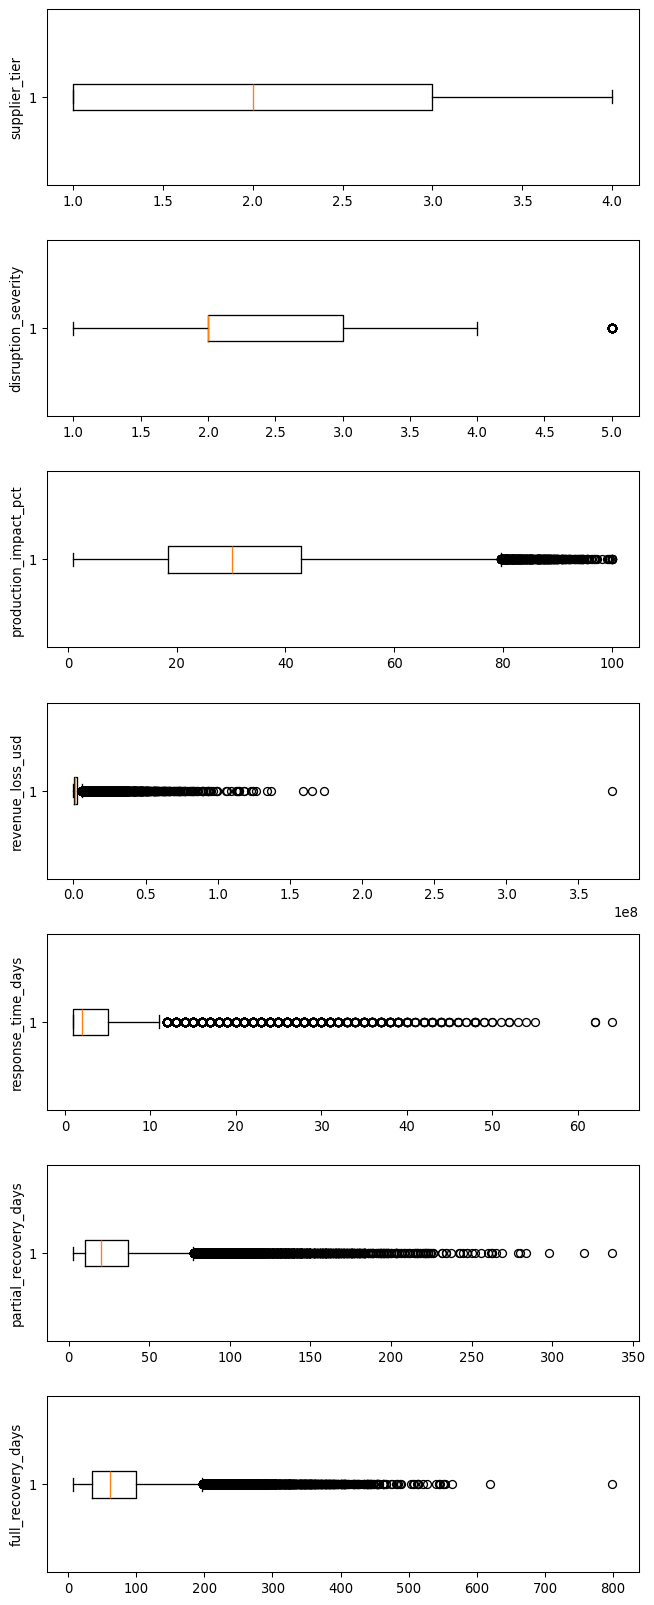

Potential outlier counts by column:
{'supplier_tier': 0, 'disruption_severity': 3791, 'production_impact_pct': 667, 'revenue_loss_usd': 10620, 'response_time_days': 7094, 'partial_recovery_days': 5190, 'full_recovery_days': 4090}


In [21]:
numeric_cols = df.select_dtypes(include=['number']).columns

fig, axs = plt.subplots(len(numeric_cols), 1, dpi=95, figsize=(7, 17))

for i, col in enumerate(numeric_cols):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Count potential outliers using IQR
outlier_counts = {}

for col in df.select_dtypes(include=[np.number]).columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

print("Potential outlier counts by column:")
print(outlier_counts)

In [22]:
outlier_counts = {}

for col in df.select_dtypes(include=[np.number]).columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

print(outlier_counts)

{'supplier_tier': 0, 'disruption_severity': 3791, 'production_impact_pct': 667, 'revenue_loss_usd': 10620, 'response_time_days': 7094, 'partial_recovery_days': 5190, 'full_recovery_days': 4090}


In [23]:
def remove_outliers_iqr(df, k=1.5, exclude_cols=None):
    """
    Remove outliers from selected numeric columns using the IQR method.

    Parameters:
        df (pd.DataFrame): Input dataframe
        k (float): IQR multiplier, default = 1.5
        exclude_cols (list): Columns to exclude from outlier filtering

    Returns:
        pd.DataFrame: Cleaned dataframe with selected outliers removed
    """
    df_clean = df.copy()

    if exclude_cols is None:
        exclude_cols = []

    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    num_cols = [col for col in num_cols if col not in exclude_cols]

    for col in num_cols:
        q1, q3 = df_clean[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr

        df_clean = df_clean[
            (df_clean[col] >= lower) & (df_clean[col] <= upper)
        ]

    return df_clean

In [24]:
exclude_cols = [
    'supplier_tier',
    'disruption_severity',
    'has_backup_supplier',
    'permanent_supplier_change'
]

# Outliers were inspected, but rows were not removed because the IQR method
# would eliminate too many valid observations from the dataset.
print("Current shape after optional outlier step:", df.shape)

Current shape after optional outlier step: (100000, 15)


Outliers were inspected using boxplots and IQR method. However, row removal was not applied because the method flagged a large number of valid observations. Removing these observations would've unnecessarily reduced the dataset size.

# Data Type Correction

In [27]:
df.dtypes

disruption_id                 object
disruption_type               object
industry                      object
supplier_tier                  int64
supplier_region               object
supplier_size                 object
has_backup_supplier             bool
disruption_severity            int64
production_impact_pct        float64
revenue_loss_usd             float64
response_type                 object
response_time_days             int64
partial_recovery_days          int64
full_recovery_days             int64
permanent_supplier_change       bool
dtype: object

In [28]:
df['has_backup_supplier'] = df['has_backup_supplier'].astype(int)
df['permanent_supplier_change'] = df['permanent_supplier_change'].astype(int)

# Drop ID safely
df = df.drop(columns=['disruption_id'], errors='ignore')

The irrelevant identifier columns were removed, and the boolean variables were converted into numeric format to ensure compatibility with machine learning models.

# Feature Engineering

In [31]:
# Severity * impact interaction
df['severity_impact'] = df['disruption_severity'] * df['production_impact_pct']

print(df[['severity_impact']].head())

   severity_impact
0            108.6
1            209.6
2             64.8
3             15.7
4             65.8


A new feature was engineered to capture a deeper relationship in the data by measuring the interaction effect between disruption severity and production impact.

# Categorical Encoding

In [34]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())
print("Encoded shape:", df_encoded.shape)

   supplier_tier  has_backup_supplier  disruption_severity  \
0              1                    0                    2   
1              2                    1                    4   
2              1                    1                    2   
3              2                    1                    1   
4              1                    1                    2   

   production_impact_pct  revenue_loss_usd  response_time_days  \
0                   54.3       11376013.16                  14   
1                   52.4        1199054.59                   1   
2                   32.4         228848.77                   1   
3                   15.7        2257287.82                   1   
4                   32.9         965588.44                   7   

   partial_recovery_days  full_recovery_days  permanent_supplier_change  \
0                      3                  59                          0   
1                     29                  97                          1   
2    

Categorical variables like disruption type, industry, and supplier region were encoded using one-hot encoding to allow machine learning models to process them effectively.

# Feature Scaling

In [37]:
# Target variable
target = 'full_recovery_days'

# Split predictors and target
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Train-test split before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale only selected continuous variables
scale_cols = [
    'production_impact_pct',
    'revenue_loss_usd',
    'response_time_days',
    'partial_recovery_days',
    'severity_impact'
]

# Keep only columns that exist
scale_cols = [col for col in scale_cols if col in X_train.columns]

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print("Scaled columns:", scale_cols)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Scaled columns: ['production_impact_pct', 'revenue_loss_usd', 'response_time_days', 'partial_recovery_days', 'severity_impact']
X_train shape: (80000, 28)
X_test shape: (20000, 28)


Feature scaling was applied only to the selected continuous variables after the train-test split to avoid data leakage and improve model performance for algorithms that are sensitive to scale.

In [39]:
output_filename = 'supplychain-preprocessed.csv'
df.to_csv(output_filename, index=False)